# Comparison Guide
This short guide serves to illustrate how to compare and visualise two different metaheuristics through search behaviour indicators.

This guide repurposes the code written in the Starter's Guide. Specifically, additional classes were defined so that we could repurpose the code for different PSOs. See the `comparison_guide_utils` for details.

## Generating Data

In [105]:
from comparison_guide_utils import Problem, IndicatorCollector, Particle
import os

# Bent Cigar function: global best at  [0, 0, 0, ..., 0], fitness = 0
def bent_cigar(x):
    return x[0] ** 2 + 1_000_000 * sum([x[k] ** 2 for k in range(1, len(x))])

bent_cigar_problem = Problem(dim=10, lower_bound=-100, upper_bound=100, fitness_function=bent_cigar)
population_size = 30

We are going to compare the impact of the cognitive and social components of a PSO. We will construct two PSOs, one with a large cognitive component and small social component, and the other with a small cognitive component and large social component. For statistical purposes, we will execute 50 runs of each of these experiments.

In [106]:
parameters_and_names = [
    ({"w": 0.9,"c1": 0.3,"c2": 1.1,},"more_social"),
    ({"w": 0.9,"c1": 1.1,"c2": 0.3,},"more_cognitive")
]

In [4]:
for parameters, name in parameters_and_names:
    for experiment in range(50):
        collector = IndicatorCollector(population_size, bent_cigar_problem)
        swarm = [Particle(parameters.values(), bent_cigar_problem, collector) for _ in range(population_size)]
        global_best = swarm[0].position.copy()  # just to start off with
        global_best_fitness = swarm[0].fitness
        global_best_index = 0
        for its in range(500):
            for index in range(population_size):
                particle = swarm[index]
                particle.update_personal_best()
                if particle.fitness < global_best_fitness:
                    global_best_index = index
                    collector.mobility(its, global_best, particle.position)
                    global_best = particle.position.copy()
                    global_best_fitness = particle.fitness
                particle.update(global_best, index, global_best_index)
            collector.fitness_csv(global_best_fitness)
            collector.f_percent(swarm)
            collector.diversity(swarm)
        if not os.path.exists(f"{name}/experiment_{experiment}"):
            os.makedirs(f"{name}/experiment_{experiment}")
        collector.write_to_path(f"{name}/experiment_{experiment}", 500, global_best_index, 0)

Now we will calculate all the indicator values, and collect everything into one dataframe.

In [107]:
import pandas as pd
from behavioural_benchmark.indicators import Indicators
indicators = ["DRoC Type A", "ERT Diversity", "Critical Diversity", "Critical Fitness", "MRoC Type B", "Critical Mobility", "ntotal*", "nshared*", "Mean ID", "Mean GC", "SNID", "EXPLORE%", "INFEASIBLE%"]

In [108]:
results = []
for _, name in parameters_and_names:
    for experiment in range(50):
        i = Indicators(path=f"{name}/experiment_{experiment}")
        droc_a, ert_div, crit_div = i.get_DRoC_A(), i.get_ERT_Diversity(), i.get_Critical_Diversity()
        crit_fit = i.get_Critical_Fitness()
        mroc_b, crit_mob = i.get_MRoC_B(), i.get_Critical_Mobility()
        ntotal, nshared = i.get_ntotal_star(), i.get_nshared_star()
        mid, mgc, snid = i.get_MID(), i.get_MGC(), i.get_SNID()
        explore, infeasible = i.get_EXPLORE_percent(), i.get_INFEASIBLE_percent()
        results.append([name, experiment, droc_a, ert_div, crit_div, crit_fit, mroc_b, crit_mob, ntotal, nshared, mid, mgc, snid, explore, infeasible])


In [109]:
df = pd.DataFrame(results, columns=["name", "experiment"] + indicators)

In [110]:
df.head()

,name,experiment,DRoC Type A,ERT Diversity,Critical Diversity,Critical Fitness,MRoC Type B,Critical Mobility,ntotal*,nshared*,Mean ID,Mean GC,SNID,EXPLORE%,INFEASIBLE%
0,more_social,0,0.130974,135.542137,118.389996,1.443194e+08,-0.142264,58.957392,7018,488,3.415094,0.919497,64.850,31.176085,21.146667
1,more_social,1,-0.538192,218.338163,10.113120,3.024437e+08,-0.041372,15.995769,6390,357,3.187845,0.927072,52.576,21.522023,8.353333
2,more_social,2,-0.919792,156.379202,29.100520,1.245144e+08,-0.011740,8.136643,7359,539,2.955720,0.934809,56.112,24.899571,68.306667
3,more_social,3,0.362511,232.118721,172.517258,2.630871e+08,-0.558942,116.342922,6292,521,4.411523,0.886283,99.802,33.937494,38.673333
4,more_social,4,-0.568631,163.000013,61.665437,4.143258e+08,-0.012071,25.182495,7480,618,2.845426,0.938486,59.716,37.564964,62.080000


## Visualisation & Comparison

To start off with, I want to do some very basic, _dry_ visualisation. I want to get an idea of the differences over all the indicators, so I will plot some distribution  plots of the results we got for each type of PSO.

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("white")
sns.set_palette(["#7A33FF", "#00F587"])

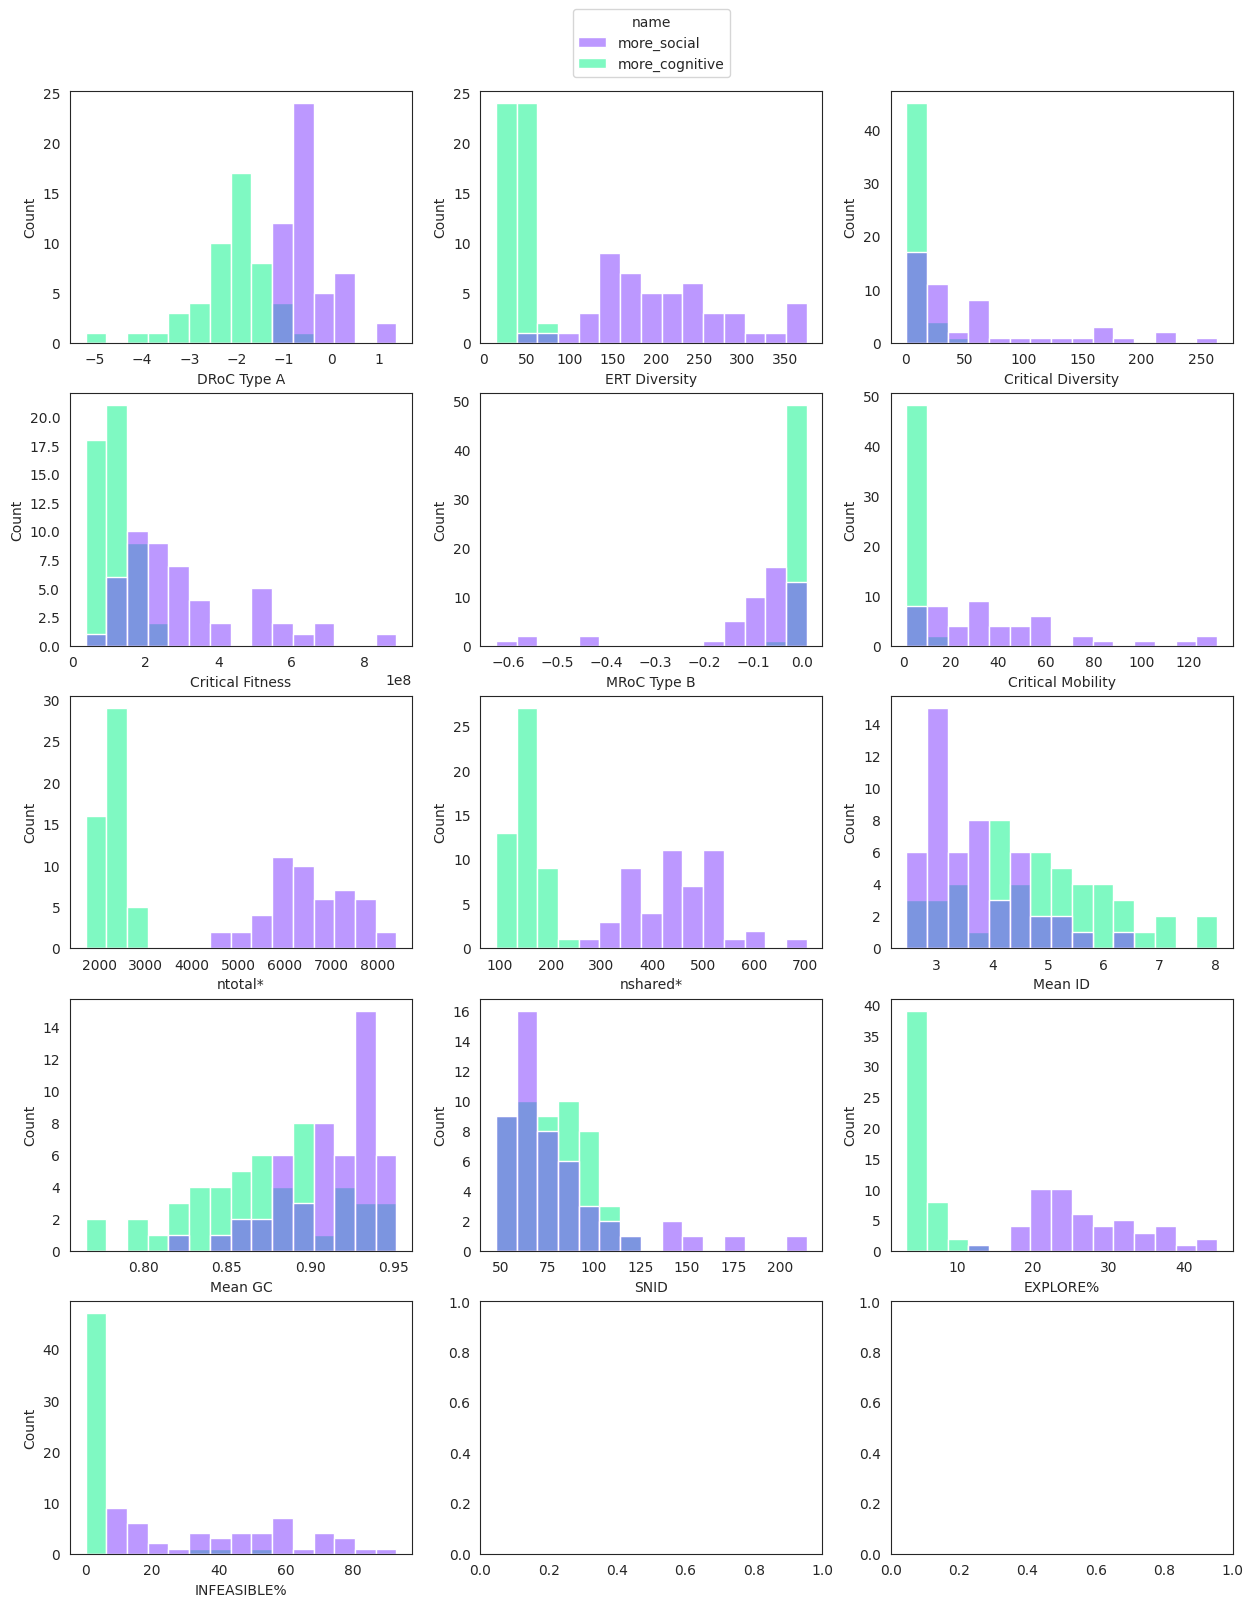

In [112]:
fig, axs = plt.subplots(5, 3, figsize=(15, 19))
for i in range(5):
    for j in range(3):
        if i*3 + j >= 13: continue
        legend = i == 0 and j == 1
        sns.histplot(data=df, hue="name", x=indicators[i*3 + j], ax=axs[i, j], bins=15, legend=legend, multiple="layer")
        if legend:
            sns.move_legend(axs[i, j], "upper center", bbox_to_anchor=(0.5, 1.35))
plt.show()

That was functional, I guess, but not very interesting. We get a good idea of how the distributions differ, but I feel like it's difficult to quantify how similar or dissimilar these PSOs are.

I want to get a feeling of the "shape" of each distribution. In my mind, the shape of the distribution represents the area within which you can expect the behaviour of any run of the metaheuristic to fall.

One small step towards this is switching to a plot type that smoothes the distribution data.

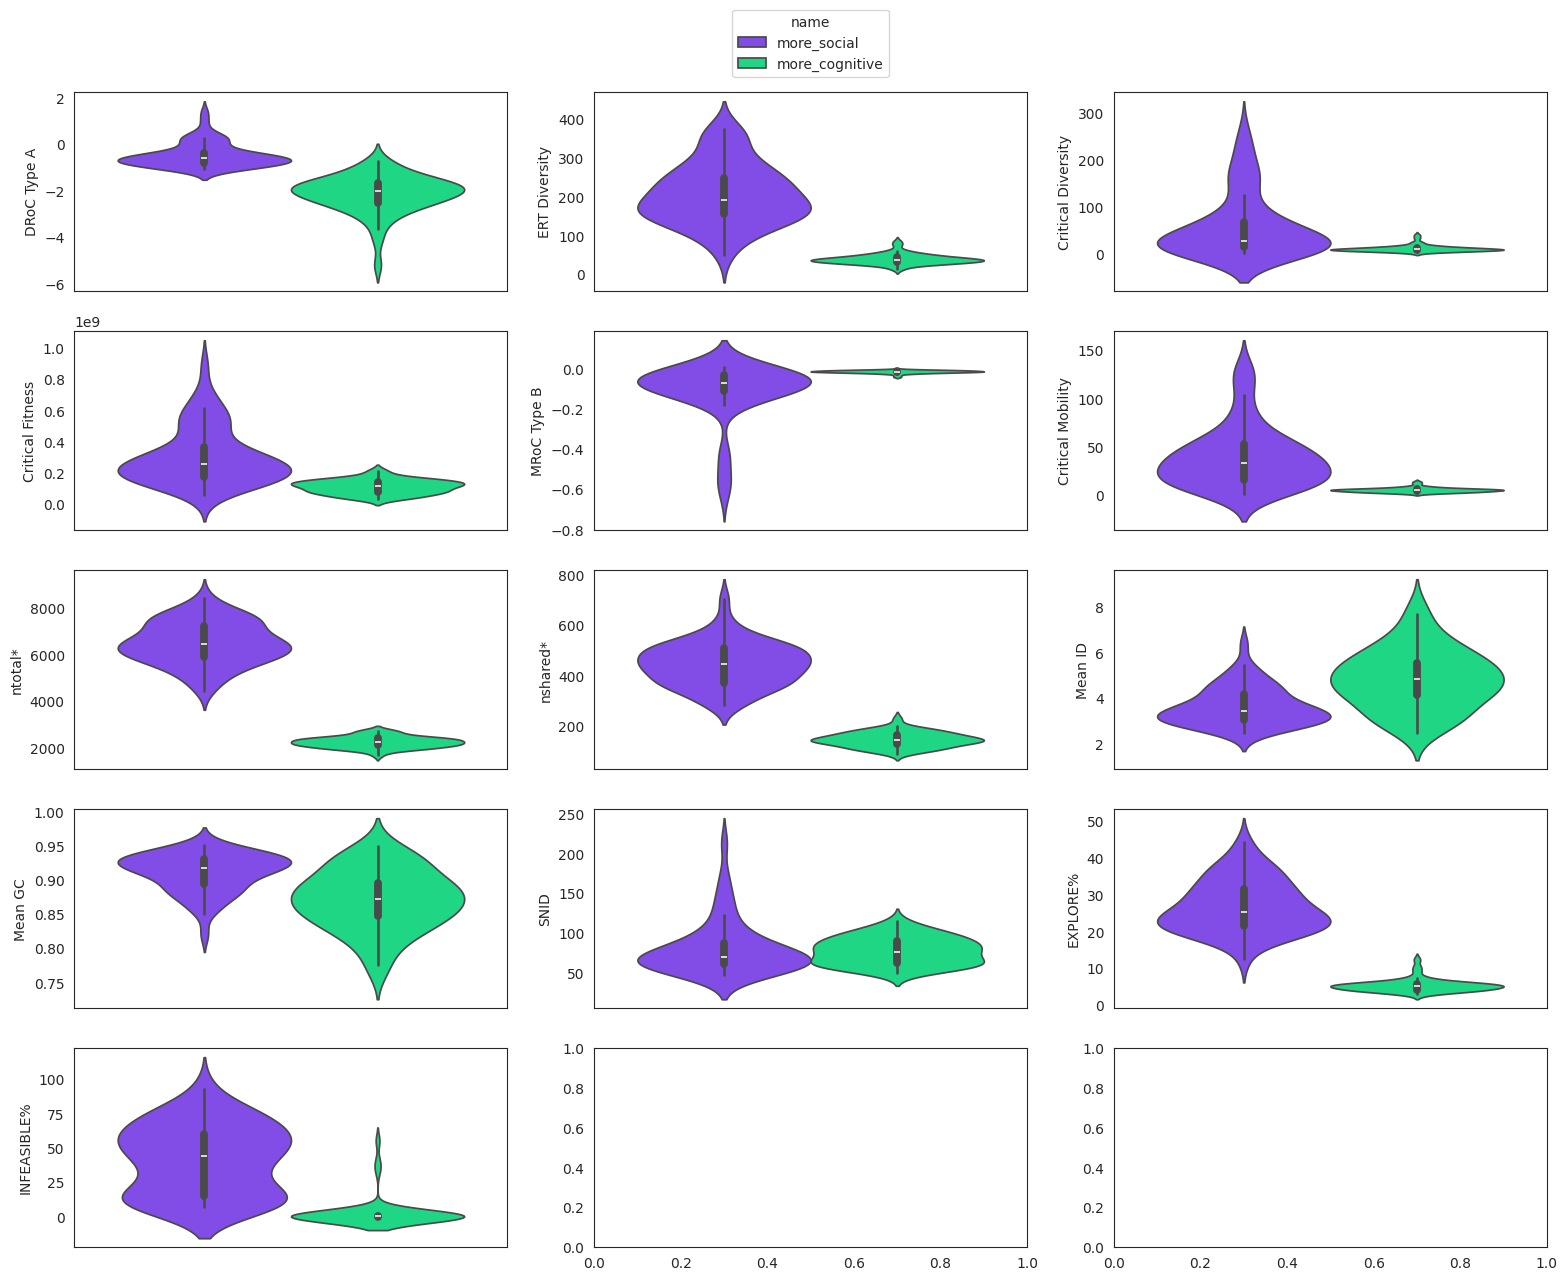

In [113]:
fig, axs = plt.subplots(5, 3, figsize=(19, 15))
for i in range(5):
    for j in range(3):
        if i*3 + j >= 13: continue
        legend = i == 0 and j == 1
        sns.violinplot(data=df, hue="name", y=indicators[i*3 + j], ax=axs[i, j], legend=legend)
        if legend:
            sns.move_legend(axs[i, j], "upper center", bbox_to_anchor=(0.5, 1.45))
plt.show()

That's definitely a step in the right direction. For each indicator, I can get an idea of how the overal behaviour profile of each metaheuristic differs. But, I still want something more. Particularly, I want to work towards putting indicators together so that we are not looking at one at a time.


I have an idea to use KDEs for this purpose.
For starters, let's look at a KDE of something that according to the plots above, overlaps significantly:

<Axes: xlabel='SNID', ylabel='Density'>

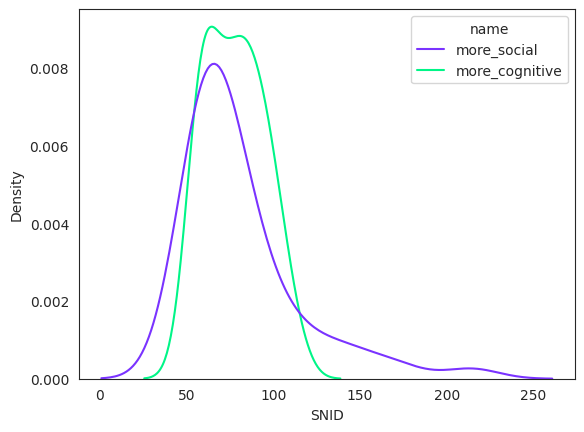

In [114]:
sns.kdeplot(data=df, hue="name", x="SNID")

That works pretty well, and I can include a second indicator on the other axis. For now I will just pick something random that also has significant overlap according to the initial visualisation.

<Axes: xlabel='SNID', ylabel='DRoC Type A'>

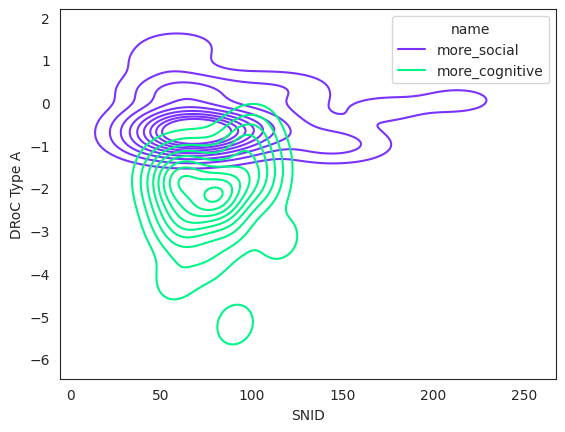

In [115]:
sns.kdeplot(df, hue="name", x="SNID", y="DRoC Type A")

That's nice! It's a nice abstraction to show how two metaheuristics overlap in some regards and not in others.
I think we can improve this visualisation by tweaking the inputs a little.

<Axes: xlabel='SNID', ylabel='DRoC Type A'>

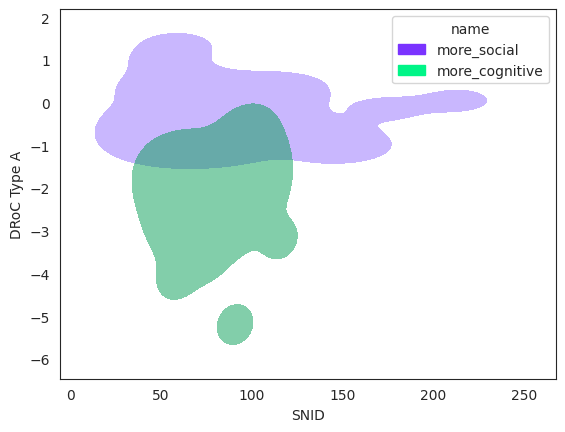

In [116]:
sns.kdeplot(df, x="SNID", hue="name", y="DRoC Type A", fill=True, alpha=0.5, levels=2)

I like this because it's less busy, but we have lost some information as to the frequency of the distribution. I think we can add that back in an even better way than it was before by plotting the data points on top.

<Axes: xlabel='SNID', ylabel='DRoC Type A'>

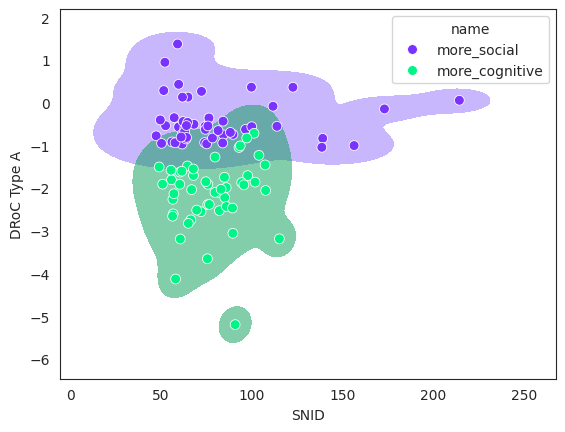

In [117]:
sns.kdeplot(df, x="SNID", hue="name", y="DRoC Type A", fill=True, alpha=0.5, levels=2, common_norm=False)
sns.scatterplot(df, x="SNID", hue="name", y="DRoC Type A", s=50, marker="o")

And that, I think, shows why this is cool - we can see that:
- The KDE represents a larger surface area than there are actually data points. We can control this with the smoothness of the KDE, but I like that this represents a larger trend than just the data points we have.
- The majority of the "more social" data points lie within "more cognitive". This indicates that while they are different, it is possible to get very similar behaviour from some runs of each metaheuristic.

Let's pair off the indicators to make a couple more of these. Technically we could do 13-choose-2 variations, but I don't want to do that. Instead, I'll grab three pairs that I used in a paper, soon to be published.

These pairs are (Critical Fitness and MRoC Type B), (ntotal* and INFEASIBLE%), and (Mean ID and SNID).

In [118]:
grouped_indicators = (
    ["Critical Fitness", 'MRoC Type B'],
    ["ntotal*",  "INFEASIBLE%"],
    ["Mean ID", "SNID"]
)

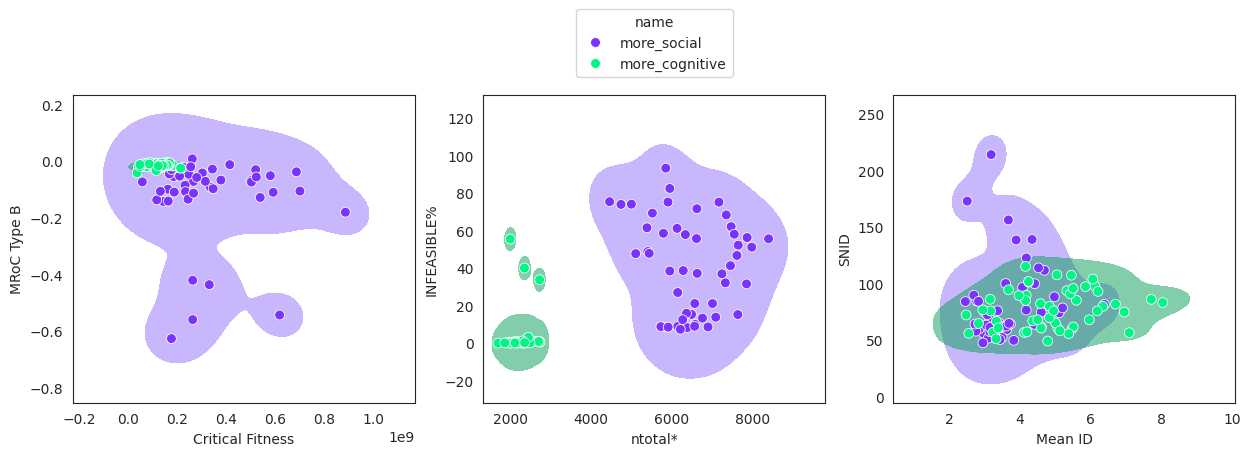

In [119]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i in range(len(grouped_indicators)):
    group = grouped_indicators[i]
    legend = i == 1
    sns.kdeplot(df, x=group[0], hue="name", y=group[1], fill=True, alpha=0.5, levels=2, ax=axs[i], legend=legend, common_norm=False)
    sns.scatterplot(df, x=group[0], hue="name", y=group[1], s=50, marker="o", ax=axs[i], legend=legend)
    if legend:
            sns.move_legend(axs[i], "upper center", bbox_to_anchor=(0.5, 1.3))
plt.show()

Awesome! I love that this shows how in different aspects of behaviour, we see distinct difference between the metaheuristics. In the first figure, the cognitive metaheuristic's behaviour is completely consumed by the social metaheuristic. In the second figure, the behaviour of the two metaheuristics is totally different. In the final figure, there are aspects of shared behaviour, but each metaheuristic also displays behaviours not displayed by the others.